<a href="https://colab.research.google.com/github/nicolePalo/flood-control-news-sentiment/blob/main/Sentiment_Analysis_and_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --no-deps bertopic
!pip install --upgrade numpy pandas scikit-learn tqdm plotly pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 161.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 158.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 166.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 152.2 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pa

In [ ]:
!pip install umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 74.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bertopic 0.17.3 requires sentence-transformers>=0.4.1, which is not installed.


In [ ]:
!pip install model2vec

In [ ]:
import pandas as pd
from bertopic import BERTopic
from model2vec import StaticModel
from transformers import pipeline

ModuleNotFoundError: No module named 'bertopic'

In [ ]:
#load datasets

import pandas as pd

youtube_corpus = pd.read_csv('/content/drive/MyDrive/Datasets/cleaned_youtube_corpus_v2.csv', index_col=0)
inquirer_corpus = pd.read_csv('/content/drive/MyDrive/Datasets/cleaned_inquirer_corpus_v2.csv', index_col=0)

youtube_corpus['date_published'] = pd.to_datetime(youtube_corpus['date_published'])
inquirer_corpus['date_published'] = pd.to_datetime(inquirer_corpus['date_published'])

In [ ]:
youtube_corpus.head()

,Unnamed: 0,title,link,date_published,text,like_count,reply_parent_id,cleaned_text
0,0,Military Junta tulad Ng Mynmar para may Justic...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-09-29 11:13:48+00:00,Military Junta tulad Ng Mynmar para may Justic...,0,NaN,military junta mynmar kulong
1,1,Good evening TV patrol,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-29 11:44:47+00:00,Good evening TV patrol,0,NaN,evening tv patrol
2,2,Watching from cebu ❤❤❤❤❤,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-29 10:22:06+00:00,Watching from cebu ❤❤❤❤❤,0,NaN,watching cebu
3,3,Imposibleng bilanggo pa nananakit ng BJMP 🤣🤣🤣p...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-28 10:49:36+00:00,Imposibleng bilanggo pa nananakit ng BJMP 🤣🤣🤣p...,0,NaN,imposibleng bilanggo nananakit bjmp pinapatawa...
4,4,Akala live July 29 eh,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-28 09:54:01+00:00,Akala live July 29 eh,0,NaN,akala live


In [ ]:
inquirer_corpus.head()

,Unnamed: 0,title,link,date_published,text,cleaned_text
0,0,Dean Asistio denies Discaya claims: ‘I have no...,https://newsinfo.inquirer.net/2146857/i-have-n...,2025-11-26 20:27:00,"MANILA, Philippines — Caloocan City 3rd Distri...",rd dean asistio denied bagman debunked accusat...
1,1,2 solons believe they can clear names despite ...,https://newsinfo.inquirer.net/2146813/2-solons...,2025-11-26 18:13:00,"MANILA, Philippines — At least two House of Re...",least expressed confidence clear names despite...
2,2,PNP: ‘Coddlers’ of 8 at-large in Mindoro flood...,https://newsinfo.inquirer.net/2146272/pnp-codd...,2025-11-25 22:04:00,"MANILA, Philippines — Acting Philippine Nation...",acting police pnp lt gen jose melencio nartate...
3,3,Arjo Atayde appears before ICI hearing: I will...,https://newsinfo.inquirer.net/2145904/arjo-ata...,2025-11-25 11:20:00,"MANILA, Philippines — Quezon City 1st District...",quezon juan carlos appeared saying going anywh...
4,4,PPP Rep. Duterte backs charges vs those linked...,https://newsinfo.inquirer.net/2145641/ppp-rep-...,2025-11-24 20:51:00,"MANILA, Philippines — Puwersa ng Pilipinong Pa...",puwersa pilipinong pandagat ppp harold welcome...


In [ ]:
youtube_corpus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22262 entries, 0 to 22261
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   Unnamed: 0       22262 non-null  int64              
 1   title            22262 non-null  object             
 2   link             22262 non-null  object             
 3   date_published   22262 non-null  datetime64[ns, UTC]
 4   text             22260 non-null  object             
 5   like_count       22262 non-null  int64              
 6   reply_parent_id  1767 non-null   object             
 7   cleaned_text     21795 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(2), object(5)
memory usage: 1.5+ MB


In [ ]:
youtube_corpus = youtube_corpus.dropna(subset=['cleaned_text'])

In [ ]:
inquirer_corpus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 537 entries, 0 to 901
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           537 non-null    object
 1   link            537 non-null    object
 2   date_published  537 non-null    object
 3   text            537 non-null    object
 4   cleaned_text    537 non-null    object
 5   words           537 non-null    object
dtypes: object(6)
memory usage: 29.4+ KB


##EDA

In [ ]:
#get 50 most frequent terms


#BERTopic

In [ ]:
embedding_model = StaticModel.from_pretrained("minishlab/potion-base-8M")

model.safetensors:   0%|          | 0.00/30.2M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/202 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import umap
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
umap_model = umap.UMAP(n_neighbors=50, n_components=10, min_dist=0.0, metric='cosine')
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")

topic_model = BERTopic(vectorizer_model=vectorizer_model,
                       umap_model=umap_model,
                       hdbscan_model=hdbscan_model)




In [ ]:
inq_timestamps = inquirer_corpus.date_published.to_list()
articles = inquirer_corpus.cleaned_text.to_list()

In [ ]:
topics, probs = topic_model.fit_transform(articles)
inquirer_corpus['topic'] = topics

2025-11-29 12:47:55,192 - BERTopic - Embedding - Transforming documents to embeddings.
2025-11-29 12:47:55,246 - BERTopic - Embedding - Completed ✓
2025-11-29 12:47:55,246 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-29 12:47:58,537 - BERTopic - Dimensionality - Completed ✓
2025-11-29 12:47:58,538 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-29 12:47:58,642 - BERTopic - Cluster - Completed ✓
2025-11-29 12:47:58,644 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-29 12:47:58,724 - BERTopic - Representation - Completed ✓


In [ ]:
inquirer_corpus.head()

,Unnamed: 0,title,link,date_published,text,cleaned_text,sentiment,confidence,topic
0,0,Dean Asistio denies Discaya claims: ‘I have no...,https://newsinfo.inquirer.net/2146857/i-have-n...,2025-11-26 20:27:00,"MANILA, Philippines — Caloocan City 3rd Distri...",rd dean asistio denied bagman debunked accusat...,Negative,0.513053,-1
1,1,2 solons believe they can clear names despite ...,https://newsinfo.inquirer.net/2146813/2-solons...,2025-11-26 18:13:00,"MANILA, Philippines — At least two House of Re...",least expressed confidence clear names despite...,Neutral,0.546964,-1
2,2,PNP: ‘Coddlers’ of 8 at-large in Mindoro flood...,https://newsinfo.inquirer.net/2146272/pnp-codd...,2025-11-25 22:04:00,"MANILA, Philippines — Acting Philippine Nation...",acting police pnp lt gen jose melencio nartate...,Negative,0.598726,0
3,3,Arjo Atayde appears before ICI hearing: I will...,https://newsinfo.inquirer.net/2145904/arjo-ata...,2025-11-25 11:20:00,"MANILA, Philippines — Quezon City 1st District...",quezon juan carlos appeared saying going anywh...,Neutral,0.650901,7
4,4,PPP Rep. Duterte backs charges vs those linked...,https://newsinfo.inquirer.net/2145641/ppp-rep-...,2025-11-24 20:51:00,"MANILA, Philippines — Puwersa ng Pilipinong Pa...",puwersa pilipinong pandagat ppp harold welcome...,Neutral,0.626117,0


In [ ]:
topics, probs = topic_model.fit_transform(articles)
hierarchical_topics = topic_model.hierarchical_topics(articles)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

2025-11-29 12:42:55,218 - BERTopic - Embedding - Transforming documents to embeddings.
2025-11-29 12:42:55,273 - BERTopic - Embedding - Completed ✓
2025-11-29 12:42:55,274 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-29 12:42:58,536 - BERTopic - Dimensionality - Completed ✓
2025-11-29 12:42:58,537 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-29 12:42:58,642 - BERTopic - Cluster - Completed ✓
2025-11-29 12:42:58,644 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-29 12:42:58,730 - BERTopic - Representation - Completed ✓
100%|██████████| 17/17 [00:00<00:00, 404.10it/s]


In [ ]:
topics, probs = topic_model.fit_transform(articles)
topic_model.visualize_barchart()

In [ ]:


topics, probs = topic_model.fit_transform(articles)

topics_over_time = topic_model.topics_over_time(articles, inq_timestamps, global_tuning=True, evolution_tuning=True, nr_bins=20)

topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)

In [ ]:
abs_timestamps = youtube_corpus.date_published.to_list()
comments = youtube_corpus.cleaned_text.to_list()
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(comments)

print(topics)

topics_over_time = topic_model.topics_over_time(comments, abs_timestamps, evolution_tuning=True, nr_bins=20)

topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)


NameError: name 'youtube_corpus' is not defined

In [ ]:
topics, probs = topic_model.fit_transform(comments)
youtube_corpus['topic'] = topics
youtube_corpus.head()


2025-11-29 12:49:16,633 - BERTopic - Embedding - Transforming documents to embeddings.
2025-11-29 12:49:16,772 - BERTopic - Embedding - Completed ✓
2025-11-29 12:49:16,773 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-29 12:49:35,962 - BERTopic - Dimensionality - Completed ✓
2025-11-29 12:49:35,963 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-29 12:49:38,643 - BERTopic - Cluster - Completed ✓
2025-11-29 12:49:38,649 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-29 12:49:39,583 - BERTopic - Representation - Completed ✓


,Unnamed: 0,title,link,date_published,text,like_count,reply_parent_id,cleaned_text,sentiment,confidence,topic
0,0,Military Junta tulad Ng Mynmar para may Justic...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-09-29 11:13:48+00:00,Military Junta tulad Ng Mynmar para may Justic...,0,NaN,military junta mynmar kulong,Negative,0.373882,211
1,1,Good evening TV patrol,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-29 11:44:47+00:00,Good evening TV patrol,0,NaN,evening tv patrol,Neutral,0.923373,134
2,2,Watching from cebu ❤❤❤❤❤,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-29 10:22:06+00:00,Watching from cebu ❤❤❤❤❤,0,NaN,watching cebu,Neutral,0.826045,15
3,3,Imposibleng bilanggo pa nananakit ng BJMP 🤣🤣🤣p...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-28 10:49:36+00:00,Imposibleng bilanggo pa nananakit ng BJMP 🤣🤣🤣p...,0,NaN,imposibleng bilanggo nananakit bjmp pinapatawa...,Negative,0.842931,121
4,4,Akala live July 29 eh,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-28 09:54:01+00:00,Akala live July 29 eh,0,NaN,akala live,Neutral,0.865001,189


In [ ]:
topic_model.visualize_barchart()

In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(comments)

tree = topic_model.get_topic_tree(hierarchical_topics)
print(tree)

100%|██████████| 437/437 [00:01<00:00, 363.26it/s]


.
├─vico_bless_ramon_salute_job
│    ├─vico_ramon_bless_salute_mabuhay
│    │    ├─salute_bukol_ramon_sir_sayo
│    │    │    ├─■──salute_arn_vico_bahid_hinahalal ── Topic: 437
│    │    │    └─salute_bukol_ramon_sir_sayo
│    │    │         ├─salute_baguio_sir_patapusin_sayo
│    │    │         │    ├─■──salute_sir_benji_courageous_conggresman ── Topic: 308
│    │    │         │    └─■──salute_patapusin_brave_reporters_bulaga ── Topic: 131
│    │    │         └─■──salute_bukol_ramon_sir_beer ── Topic: 266
│    │    └─vico_bless_ramon_thank_mabuhay
│    │         ├─ramon_sir_miguel_nakakatawa_natulong
│    │         │    ├─■──ramon_proud_bless_miguel_simplicity ── Topic: 412
│    │         │    └─ramon_sir_nakakatawa_natulong_bilyonaryo
│    │         │         ├─■──ramon_sir_igawa_compassion_kahabaan ── Topic: 161
│    │         │         └─■──ramon_natulong_yorme_nakakatawa_sulusyunan ── Topic: 114
│    │         └─vico_bless_thank_mabuhay_love
│    │              ├─mabuhay_mahal_god

In [ ]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

#Sentiment Analysis


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load model and tokenizer
model_name = "AmaanP314/youtube-xlm-roberta-base-sentiment-multilingual"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Example DataFrame with a 'comments' column
df = pd.DataFrame({
    "comments": [
        "This video aged like honey.",   # Positive
        "This video aged like milk.",    # Negative
        "It was just okay."              # Neutral
    ]
})

# Tokenize the comments column
inputs = tokenizer(df["comments"].tolist(), return_tensors="pt", padding=True, truncation=True)

# Run inference
with torch.no_grad():
    outputs = model(**inputs)

# Get predictions
predictions = torch.argmax(outputs.logits, dim=1)

# Map labels
label_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}
df["sentiment"] = [label_mapping[p.item()] for p in predictions]

print(df)


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/972 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


                      comments sentiment
0  This video aged like honey.  Positive
1   This video aged like milk.  Negative
2            It was just okay.   Neutral


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Load model and tokenizer
model_name = "AmaanP314/youtube-xlm-roberta-base-sentiment-multilingual"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

label_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}

def classify_text(text, max_length=512):
    """Chunk long text into max_length segments and average sentiment scores."""
    # Tokenize into IDs
    tokens = tokenizer.encode(text, add_special_tokens=True)

    # Split into chunks of max_length
    chunks = [tokens[i:i+max_length] for i in range(0, len(tokens), max_length)]

    sentiments = []
    confidences = []

    for chunk in chunks:
        inputs = torch.tensor([chunk])
        with torch.no_grad():
            outputs = model(inputs)
        probs = F.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

        sentiments.append(pred)
        confidences.append(probs[0, pred].item())

    # Aggregate: majority vote for label, average confidence
    final_pred = max(set(sentiments), key=sentiments.count)
    final_conf = sum(confidences) / len(confidences)

    return label_mapping[final_pred], final_conf

# Batch process
batch_size = 16
sentiments, confidences = [], []

for i in range(0, len(inquirer_corpus), batch_size):
    batch = inquirer_corpus["text"].tolist()[i:i+batch_size]
    for text in batch:
        sentiment, confidence = classify_text(text)
        sentiments.append(sentiment)
        confidences.append(confidence)

inquirer_corpus["sentiment"] = sentiments
inquirer_corpus["confidence"] = confidences

FILE_NAME = '/content/drive/MyDrive/Datasets/inquirer_sentiment.csv'
inquirer_corpus.to_csv(FILE_NAME)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/972 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

In [ ]:
inquirer_corpus.head()

,title,link,date_published,text,cleaned_text,words,sentiment,confidence
0,Dean Asistio denies Discaya claims: ‘I have no...,https://newsinfo.inquirer.net/2146857/i-have-n...,2025-11-26 20:27:00,"MANILA, Philippines — Caloocan City 3rd Distri...",caloocan rd dean asistio denied bagman debunke...,"['manila', 'philippines', 'caloocan', 'city', ...",Negative,0.513053
1,2 solons believe they can clear names despite ...,https://newsinfo.inquirer.net/2146813/2-solons...,2025-11-26 18:13:00,"MANILA, Philippines — At least two House of Re...",least expressed confidence clear names despite...,"['manila', 'philippines', 'at', 'least', 'two'...",Neutral,0.546964
2,PNP: ‘Coddlers’ of 8 at-large in Mindoro flood...,https://newsinfo.inquirer.net/2146272/pnp-codd...,2025-11-25 22:04:00,"MANILA, Philippines — Acting Philippine Nation...",acting philippine police pnp lt gen jose melen...,"['manila', 'philippines', 'acting', 'philippin...",Negative,0.598726
3,Arjo Atayde appears before ICI hearing: I will...,https://newsinfo.inquirer.net/2145904/arjo-ata...,2025-11-25 11:20:00,"MANILA, Philippines — Quezon City 1st District...",quezon juan carlos arjo atayde appeared saying...,"['manila', 'philippines', 'quezon', 'city', 's...",Neutral,0.650901
4,PPP Rep. Duterte backs charges vs those linked...,https://newsinfo.inquirer.net/2145641/ppp-rep-...,2025-11-24 20:51:00,"MANILA, Philippines — Puwersa ng Pilipinong Pa...",puwersa pilipinong pandagat ppp harold duterte...,"['manila', 'philippines', 'puwersa', 'ng', 'pi...",Neutral,0.626117


In [ ]:
batch_size = 16
sentiments, confidences = [], []

for i in range(0, len(youtube_corpus), batch_size):
    batch = youtube_corpus["text"].tolist()[i:i+batch_size]
    print("batch")
    for text in batch:
        print("new text")
        sentiment, confidence = classify_text(text)
        sentiments.append(sentiment)
        confidences.append(confidence)

youtube_corpus["sentiment"] = sentiments
youtube_corpus["confidence"] = confidences

FILE_NAME = '/content/drive/MyDrive/Datasets/youtube_sentiment.csv'
youtube_corpus.to_csv(FILE_NAME)

Streaming output truncated to the last 5000 lines.
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
batch
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
batch
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
batch
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
batch
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
batch
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
new text
batch
new text
new text
new text
new text
new text
new text
new 

In [ ]:
youtube_corpus.head(20)

,Unnamed: 0,title,link,date_published,text,like_count,reply_parent_id,cleaned_text,sentiment,confidence
0,0,Military Junta tulad Ng Mynmar para may Justic...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-09-29 11:13:48+00:00,Military Junta tulad Ng Mynmar para may Justic...,0,NaN,military junta mynmar kulong,Negative,0.373882
1,1,Good evening TV patrol,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-29 11:44:47+00:00,Good evening TV patrol,0,NaN,evening tv patrol,Neutral,0.923373
2,2,Watching from cebu ❤❤❤❤❤,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-29 10:22:06+00:00,Watching from cebu ❤❤❤❤❤,0,NaN,watching cebu,Neutral,0.826045
3,3,Imposibleng bilanggo pa nananakit ng BJMP 🤣🤣🤣p...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-28 10:49:36+00:00,Imposibleng bilanggo pa nananakit ng BJMP 🤣🤣🤣p...,0,NaN,imposibleng bilanggo nananakit bjmp pinapatawa...,Negative,0.842931
4,4,Akala live July 29 eh,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-28 09:54:01+00:00,Akala live July 29 eh,0,NaN,akala live,Neutral,0.865001
5,5,Watching from Europe thank God walang casualti...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-08-09 19:56:35+00:00,Watching from Europe thank God walang casualti...,0,NaN,watching europe thank casualties salamat uploa...,Positive,0.901641
6,6,Dapat kase ginawa na ninyo yan noon pa .,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-07-30 04:49:22+00:00,Dapat kase ginawa na ninyo yan noon pa .,0,NaN,kase,Negative,0.586079
7,7,Persons Deprived of Liberty? Yung biktima na n...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-07-30 02:55:03+00:00,Persons Deprived of Liberty? Yung biktima na n...,0,NaN,persons deprived liberty biktima nagpakulong d...,Negative,0.909297
9,9,Totoong kakasuhan ang mga Pulis na involve sa...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-07-30 02:47:32+00:00,Totoong kakasuhan ang mga Pulis na involve sa...,0,NaN,totoong kakasuhan pulis involve nawawalngmga s...,Neutral,0.557586
11,11,Imposible naman ung preso pa nananakit sa mga...,https://www.youtube.com/watch?v=MoFLT34WOBk&lc...,2025-07-30 00:40:46+00:00,Imposible naman ung preso pa nananakit sa mga...,0,NaN,imposible preso nananakit gwardya lokohin lelong,Negative,0.876326


In [ ]:
inquirer_corpus.head()

In [ ]:
FILE_NAME = '/content/drive/MyDrive/Datasets/inquirer_sentiment.csv'
inquirer_corpus.to_csv(FILE_NAME)

In [ ]:
FILE_NAME = '/content/drive/MyDrive/Datasets/youtube_sentiment.csv'
youtube_corpus.to_csv(FILE_NAME)

In [ ]:
inquirer_sentiment = pd.read_csv('/content/drive/MyDrive/Datasets/inquirer_sentiment.csv', index_col=0)
youtube_sentiment = pd.read_csv('/content/drive/MyDrive/Datasets/youtube_sentiment.csv', index_col=0)

In [ ]:
inquirer_sentiment.head()

,Unnamed: 0,title,link,date_published,text,cleaned_text,sentiment,confidence
0,0,Dean Asistio denies Discaya claims: ‘I have no...,https://newsinfo.inquirer.net/2146857/i-have-n...,2025-11-26 20:27:00,"MANILA, Philippines — Caloocan City 3rd Distri...",rd dean asistio denied bagman debunked accusat...,Negative,0.513053
1,1,2 solons believe they can clear names despite ...,https://newsinfo.inquirer.net/2146813/2-solons...,2025-11-26 18:13:00,"MANILA, Philippines — At least two House of Re...",least expressed confidence clear names despite...,Neutral,0.546964
2,2,PNP: ‘Coddlers’ of 8 at-large in Mindoro flood...,https://newsinfo.inquirer.net/2146272/pnp-codd...,2025-11-25 22:04:00,"MANILA, Philippines — Acting Philippine Nation...",acting police pnp lt gen jose melencio nartate...,Negative,0.598726
3,3,Arjo Atayde appears before ICI hearing: I will...,https://newsinfo.inquirer.net/2145904/arjo-ata...,2025-11-25 11:20:00,"MANILA, Philippines — Quezon City 1st District...",quezon juan carlos appeared saying going anywh...,Neutral,0.650901
4,4,PPP Rep. Duterte backs charges vs those linked...,https://newsinfo.inquirer.net/2145641/ppp-rep-...,2025-11-24 20:51:00,"MANILA, Philippines — Puwersa ng Pilipinong Pa...",puwersa pilipinong pandagat ppp harold welcome...,Neutral,0.626117


In [ ]:
inquirer_sentiment['sentiment'].value_counts()

,count
sentiment,
Neutral,390
Negative,147


In [ ]:
youtube_sentiment.sentiment.value_counts()

,count
sentiment,
Negative,14511
Neutral,4005
Positive,3279


In [ ]:
inquirer_corpus.topic.value_counts()

,count
topic,
0,122
-1,73
1,67
2,38
3,34
4,33
5,21
6,19
7,17


In [ ]:
inquirer_corpus[inquirer_corpus["topic"].isin([0,1,2,3,4,5,6,7,8,9])].groupby(['topic']).sentiment.value_counts()

topic  sentiment
0      Neutral      96
       Negative     26
1      Neutral      50
       Negative     17
2      Neutral      25
       Negative     13
3      Neutral      25
       Negative      9
4      Neutral      22
       Negative     11
5      Neutral      17
       Negative      4
6      Neutral      14
       Negative      5
7      Negative     10
       Neutral       7
8      Negative     11
       Neutral       6
9      Neutral      11
       Negative      6
Name: count, dtype: int64

In [ ]:
youtube_corpus[youtube_corpus["topic"].isin([0,1,2,3,4,5,6,7,8,9])].groupby(['topic']).sentiment.value_counts()

topic  sentiment
0      Negative     372
       Neutral       64
       Positive      22
1      Negative     186
       Neutral       37
       Positive       9
2      Negative     174
       Positive      38
       Neutral       17
3      Negative     163
       Neutral       42
       Positive      22
4      Negative     111
       Neutral       78
       Positive      28
5      Negative     184
       Positive      13
       Neutral        8
6      Negative     162
       Neutral       25
       Positive       8
7      Negative     151
       Positive      21
       Neutral       20
8      Negative     120
       Neutral       37
       Positive      22
9      Negative      94
       Positive      46
       Neutral       37
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt

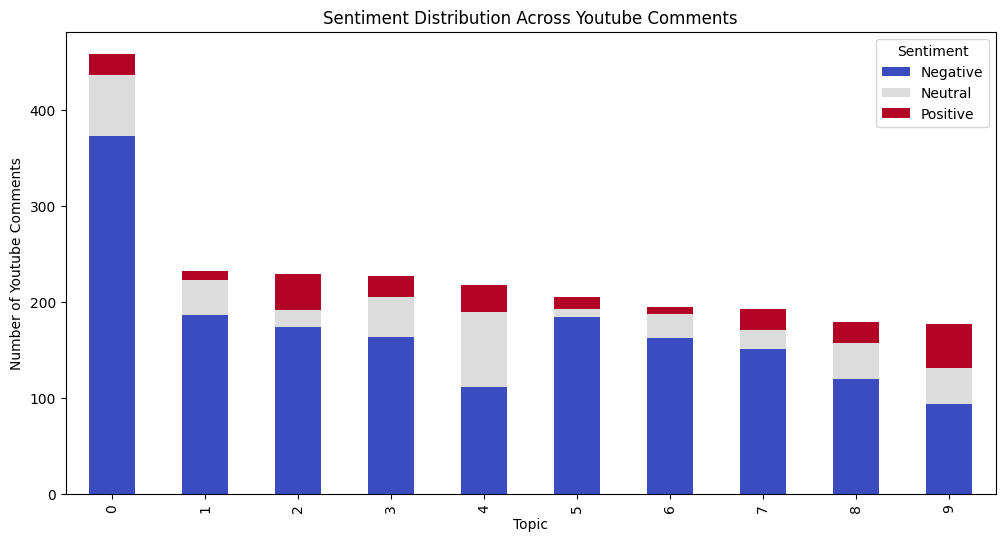

In [ ]:
df = youtube_corpus[youtube_corpus["topic"].isin([0,1,2,3,4,5,6,7,8,9])]

sentiment_counts = df.groupby(["topic", "sentiment"]).size().unstack(fill_value=0)

# Step 2: Plot stacked bar chart
sentiment_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    title="Sentiment Distribution Across Youtube Comments",
    colormap="coolwarm"  # optional: choose a nice color map
)

plt.xlabel("Topic")
plt.ylabel("Number of Youtube Comments")
plt.legend(title="Sentiment")
plt.show()

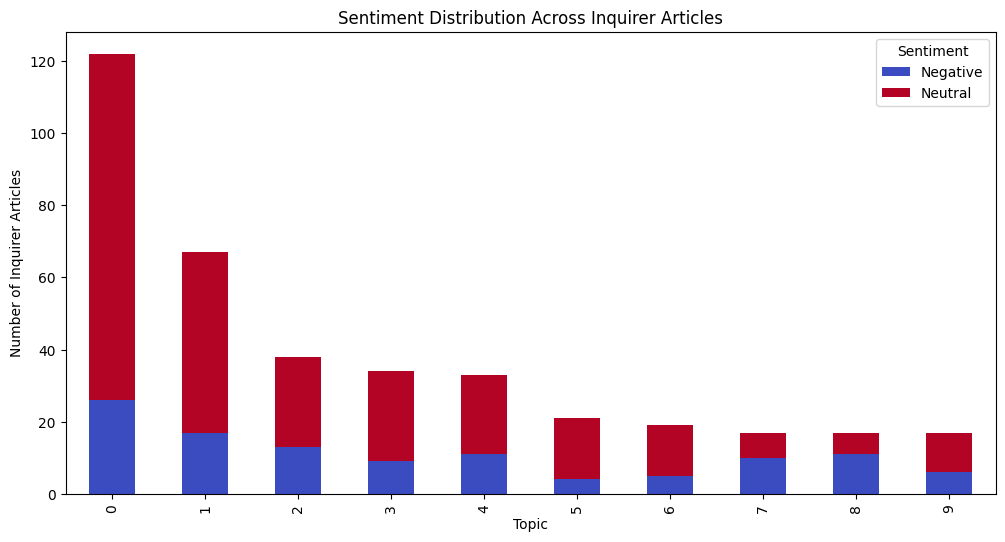

In [ ]:
df = inquirer_corpus[inquirer_corpus["topic"].isin([0,1,2,3,4,5,6,7,8,9])]

sentiment_counts = df.groupby(["topic", "sentiment"]).size().unstack(fill_value=0)

# Step 2: Plot stacked bar chart
sentiment_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    title="Sentiment Distribution Across Inquirer Articles",
    colormap="coolwarm"  # optional: choose a nice color map
)

plt.xlabel("Topic")
plt.ylabel("Number of Inquirer Articles")
plt.legend(title="Sentiment")
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2311, 11) and arg 1 with shape (21795,).

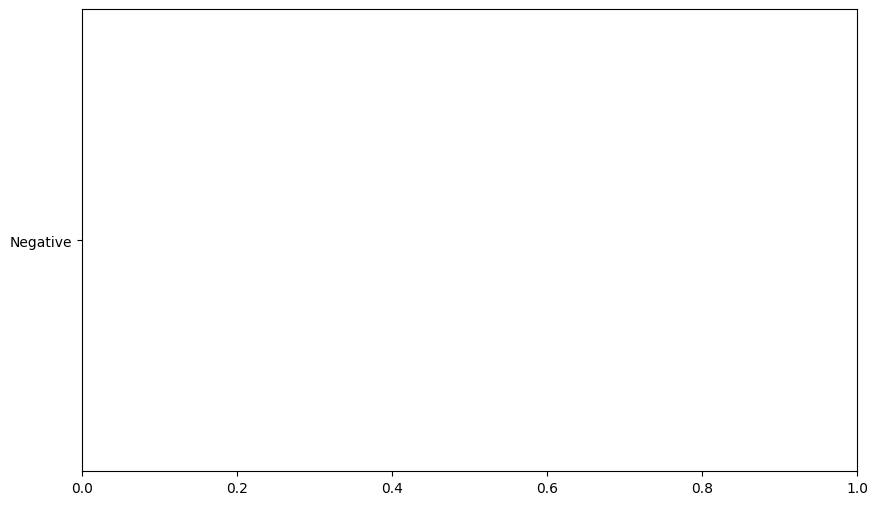

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(youtube_corpus[youtube_corpus["topic"].isin([0,1,2,3,4,5,6,7,8,9])], youtube_corpus["sentiment"], color="skyblue")
plt.xlabel("Topic")
plt.ylabel("Average Sentiment")
plt.title("Sentiment per Topic")
plt.show()

In [ ]:
youtube_corpus[youtube_corpus['topic'].isin([-1,0,1,2,3,4,5,6,7,8,9])].topic.value_counts()

,count
topic,
-1,2551
0,458
1,232
2,229
3,227
4,217
5,205
6,195
7,192


In [ ]:
inquirer_corpus[inquirer_corpus['topic'].isin([0,1,2,3,4,5,6,7,8,9])].topic.value_counts()

,count
topic,
0,122
1,67
2,38
3,34
4,33
5,21
6,19
7,17
9,17
